# SVM Binary Classification — Skin Cancer (HAM10000 Metadata)
Binary: **B=1** malignant/precancer (`mel, bcc, akiec, vasc`) vs **M=0** benign (`nv, df, bkl`)

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath('../prepare_data'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, average_precision_score, precision_recall_curve,
)

from preprocess import (
    load_data, filter_valid_dx, make_binary_label,
    build_full_pipeline, group_split, grid_search_tune_v2, tune_threshold,
    RAW_FEATURES,
)

## 1. Load & EDA

In [12]:
df = load_data('../data/HAM10000_metadata.csv')
df = filter_valid_dx(df)
print(df.shape)
print(df['dx'].value_counts())
df.info()

(10015, 8)
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
 7   dataset       10015 non-null  str    
dtypes: float64(1), str(7)
memory usage: 626.1 KB


In [13]:
print('Missing values:')
print(df.isna().sum())

Missing values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dataset          0
dtype: int64


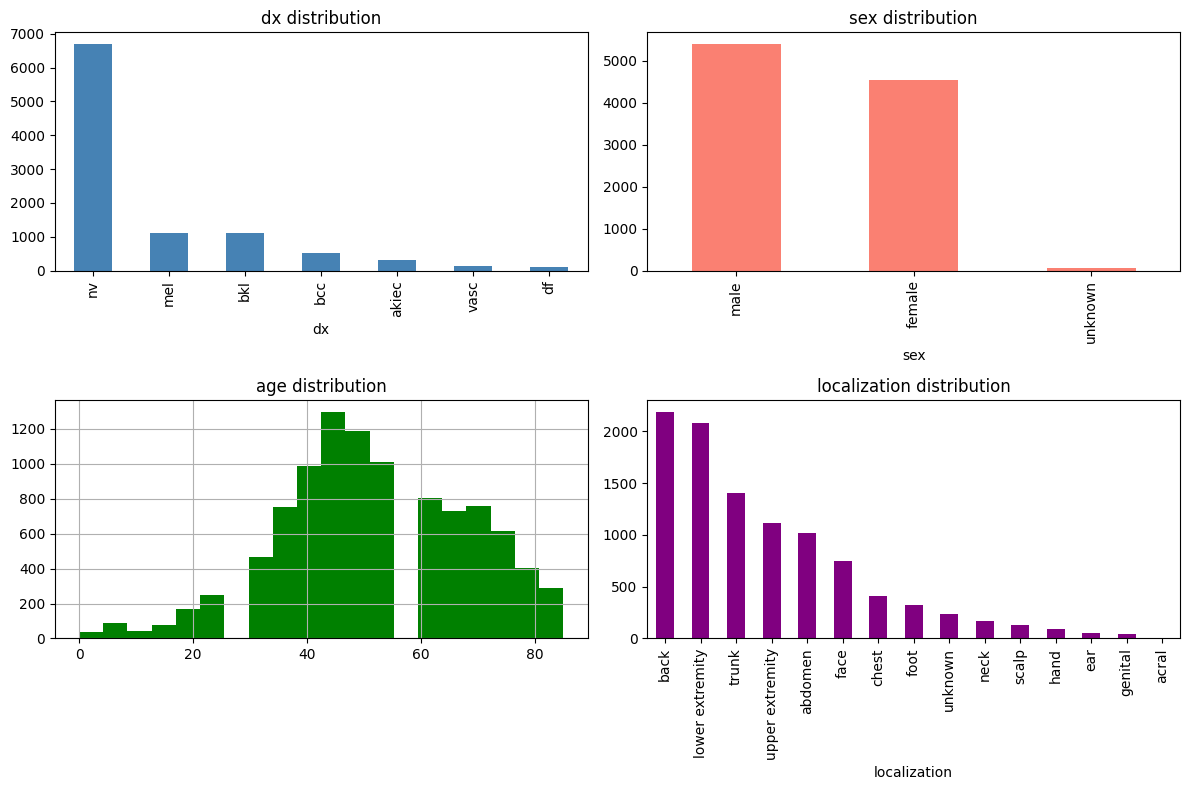

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
df['dx'].value_counts().plot(kind='bar', ax=axes[0,0], title='dx distribution', color='steelblue')
df['sex'].value_counts().plot(kind='bar', ax=axes[0,1], title='sex distribution', color='salmon')
df['age'].hist(ax=axes[1,0], bins=20, color='green')
axes[1,0].set_title('age distribution')
df['localization'].value_counts().plot(kind='bar', ax=axes[1,1], title='localization distribution', color='purple')
plt.tight_layout()
plt.show()

## 2. Preprocessing

In [15]:
df = make_binary_label(df)
print('Label distribution (0=benign, 1=malignant):')
print(df['diagnosis'].value_counts())

# Keep lesion_id (needed for group split). Drop only truly unused cols.
df = df[['lesion_id', 'age', 'sex', 'localization', 'diagnosis']]
df.head()

Label distribution (0=benign, 1=malignant):
diagnosis
0    7919
1    2096
Name: count, dtype: int64


,lesion_id,age,sex,localization,diagnosis
0,HAM_0000118,80.0,male,scalp,0
1,HAM_0000118,80.0,male,scalp,0
2,HAM_0002730,80.0,male,scalp,0
3,HAM_0002730,80.0,male,scalp,0
4,HAM_0001466,75.0,male,ear,0


## 3. Group-Aware Train/Test Split
Split by `lesion_id` to prevent leakage — same lesion can have multiple images in HAM10000.

In [16]:
df_train, df_test = group_split(df, target_col='diagnosis', group_col='lesion_id')

X_train = df_train[RAW_FEATURES]
y_train = df_train['diagnosis'].values
groups_train = df_train['lesion_id'].values

X_test  = df_test[RAW_FEATURES]
y_test  = df_test['diagnosis'].values

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Unique lesions train: {df_train["lesion_id"].nunique()}, test: {df_test["lesion_id"].nunique()}')
print(f'Lesion overlap: {len(set(df_train["lesion_id"]) & set(df_test["lesion_id"]))}')
print(f'Train class balance: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test  class balance: {dict(zip(*np.unique(y_test, return_counts=True)))}')

Train: (7991, 3), Test: (2024, 3)
Unique lesions train: 5976, test: 1494
Lesion overlap: 0
Train class balance: {np.int64(0): np.int64(6322), np.int64(1): np.int64(1669)}
Test  class balance: {np.int64(0): np.int64(1597), np.int64(1): np.int64(427)}


## 4. Hyperparameter Tuning — StratifiedGroupKFold + GridSearchCV
- Scoring: `average_precision` (PR-AUC) — robust on imbalanced binary; does not depend on threshold.
- CV: 5-fold StratifiedGroupKFold grouped by `lesion_id` to avoid leak.
- Grid: 4 × 4 × 1 = 16 combos.

In [17]:
gs = grid_search_tune_v2(X_train, y_train, groups=groups_train,
                          scoring='average_precision', n_splits=5)
print('Best params:', gs.best_params_)
print(f'Best CV PR-AUC: {gs.best_score_:.4f}')

cv_results = pd.DataFrame(gs.cv_results_)
top5 = cv_results.sort_values('mean_test_score', ascending=False).head(5)
print(top5[['param_svc__C','param_svc__gamma','param_svc__kernel','mean_test_score','std_test_score']])

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Best CV PR-AUC: 0.4495
    param_svc__C param_svc__gamma param_svc__kernel  mean_test_score  \
6            1.0             0.01               rbf         0.449466   
14         100.0             0.01               rbf         0.448819   
9           10.0            0.001               rbf         0.448542   
13         100.0            0.001               rbf         0.448331   
10          10.0             0.01               rbf         0.447789   

    std_test_score  
6         0.013034  
14        0.016853  
9         0.012411  
13        0.015656  
10        0.011040  


## 5. Evaluation
Two-stage:
1. Default threshold (0) — baseline.
2. Tune threshold on train decision scores (F2 → favor recall for cancer screening), apply to test.

In [18]:
best_pipeline = gs.best_estimator_

# Decision scores (signed distance from hyperplane)
train_scores = best_pipeline.decision_function(X_train)
test_scores  = best_pipeline.decision_function(X_test)

# --- (a) default threshold = 0 ---
y_pred_default = (test_scores >= 0).astype(int)
test_acc       = accuracy_score(y_test, y_pred_default)
test_f1_macro  = f1_score(y_test, y_pred_default, average='macro')
test_pr_auc    = average_precision_score(y_test, test_scores)
cv_pr_auc      = gs.best_score_

print('=== Default threshold (0) ===')
print(f'CV PR-AUC (mean):  {cv_pr_auc:.4f}')
print(f'Test PR-AUC:       {test_pr_auc:.4f}')
print(f'Gap (CV - test):   {abs(cv_pr_auc - test_pr_auc):.4f}')
print(f'Test accuracy:     {test_acc:.4f}')
print(f'Test f1_macro:     {test_f1_macro:.4f}')
print()
print(classification_report(y_test, y_pred_default, target_names=['Benign (0)', 'Malignant (1)']))

# --- (b) threshold tuned on TRAIN (F2 → recall-leaning) ---
best_thr, best_f2_train = tune_threshold(y_train, train_scores, beta=2.0)
y_pred_tuned = (test_scores >= best_thr).astype(int)
print(f'\n=== Tuned threshold (F2 on train) ===')
print(f'Threshold: {best_thr:.4f}  (train F2: {best_f2_train:.4f})')
print(f'Test accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'Test f1_macro: {f1_score(y_test, y_pred_tuned, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred_tuned, target_names=['Benign (0)', 'Malignant (1)']))

=== Default threshold (0) ===
CV PR-AUC (mean):  0.4495
Test PR-AUC:       0.4189
Gap (CV - test):   0.0306
Test accuracy:     0.7144
Test f1_macro:     0.6587

               precision    recall  f1-score   support

   Benign (0)       0.91      0.71      0.80      1597
Malignant (1)       0.40      0.74      0.52       427

     accuracy                           0.71      2024
    macro avg       0.66      0.72      0.66      2024
 weighted avg       0.80      0.71      0.74      2024


=== Tuned threshold (F2 on train) ===
Threshold: -0.2410  (train F2: 0.6452)
Test accuracy: 0.6458
Test f1_macro: 0.6105

               precision    recall  f1-score   support

   Benign (0)       0.92      0.60      0.73      1597
Malignant (1)       0.35      0.82      0.49       427

     accuracy                           0.65      2024
    macro avg       0.64      0.71      0.61      2024
 weighted avg       0.80      0.65      0.68      2024



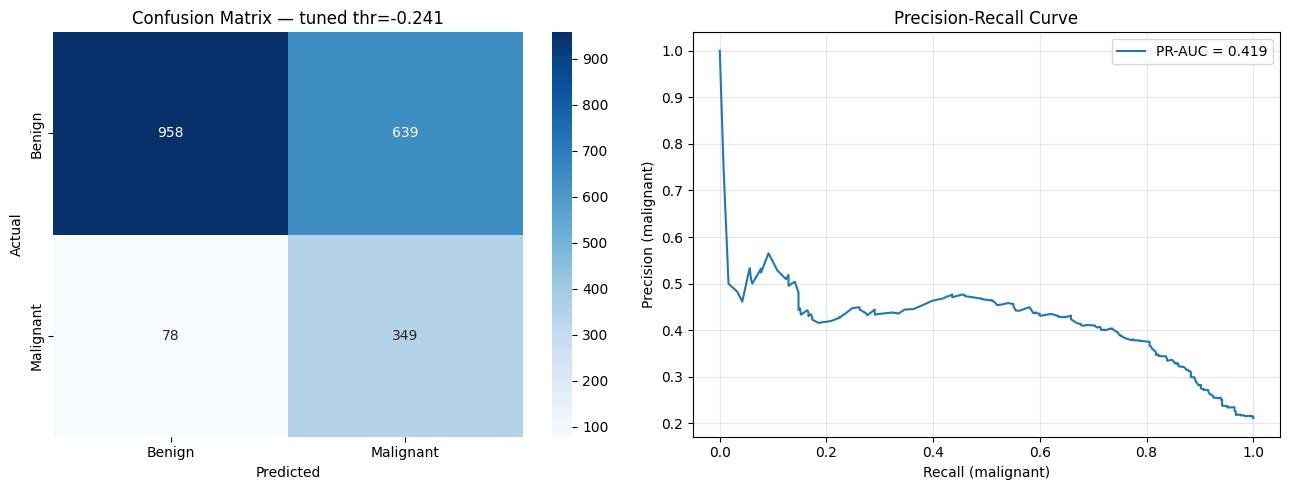

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix (tuned threshold)
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix — tuned thr={best_thr:.3f}')

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, test_scores)
axes[1].plot(rec, prec, label=f'PR-AUC = {test_pr_auc:.3f}')
axes[1].set_xlabel('Recall (malignant)')
axes[1].set_ylabel('Precision (malignant)')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Save Model

In [20]:
os.makedirs('../model', exist_ok=True)
bundle = {
    'pipeline':   best_pipeline,       # expects DataFrame[age, sex, localization]
    'features':   RAW_FEATURES,
    'threshold':  best_thr,            # apply to decision_function for binary cut
    'label_map':  {0: 'Benign', 1: 'Malignant'},
    'raw_input':  True,                # signal to app: pass raw DataFrame, not encoded array
}
joblib.dump(bundle, '../model/svm_binary_class_model.joblib')
print('Saved: ../model/svm_binary_class_model.joblib')
print(f"  threshold={best_thr:.4f}, features={RAW_FEATURES}")

Saved: ../model/svm_binary_class_model.joblib
  threshold=-0.2410, features=['age', 'sex', 'localization']
